# **LO2 – Visual Perception**

In [27]:
# === LO2: Visual Perception ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load data from GitHub ---
base_url = "https://raw.githubusercontent.com/rodrigourech/gdv/main/"
tas45 = pd.read_csv(base_url + "RCP45_tas.csv")
tas85 = pd.read_csv(base_url + "RCP85_tas.csv")
tas = pd.concat([tas45, tas85], ignore_index=True)

# --- Preprocess ---
tas["scenario"] = tas["scenario"].astype("category")
tas["date"] = pd.to_datetime(tas["date"])
tas["year"] = tas["date"].dt.year
tas["month"] = tas["date"].dt.month
tas["doy"] = tas["date"].dt.dayofyear
tas["decade"] = (tas["year"] // 10) * 10

# --- Subsets ---
stations = ["Zürich", "Lugano", "Davos"]
tas_s = tas[tas["station"].isin(stations)].copy()
tas85_zurich = tas[(tas["station"] == "Zürich") & (tas["scenario"] == "RCP85")].copy()


C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_30576\549816679.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ann = tas.groupby(["scenario", "year"], as_index=False)["value"].mean()


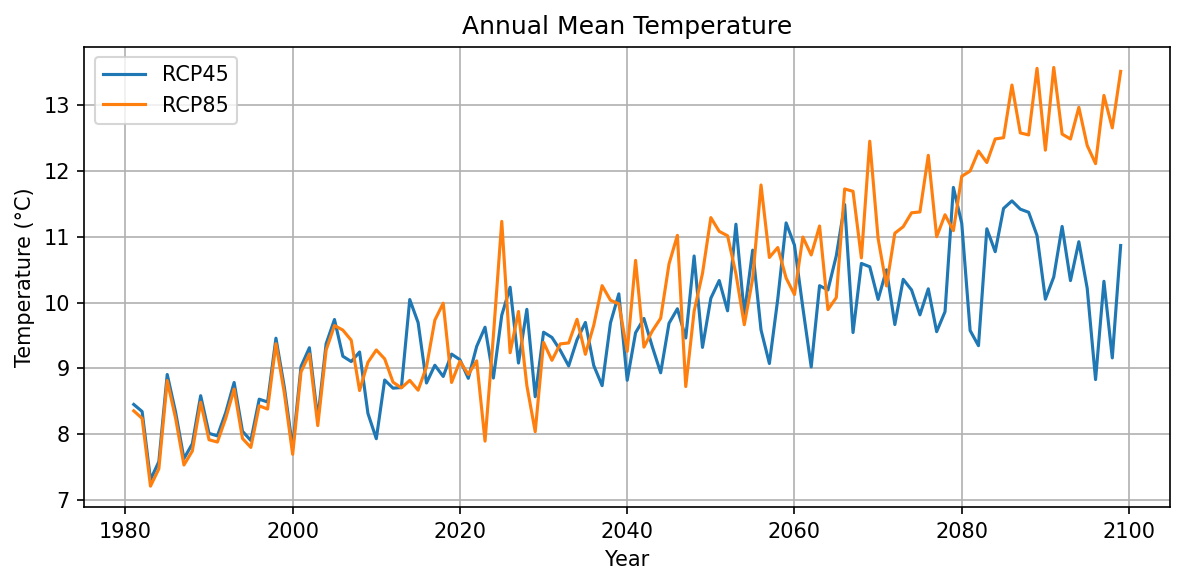

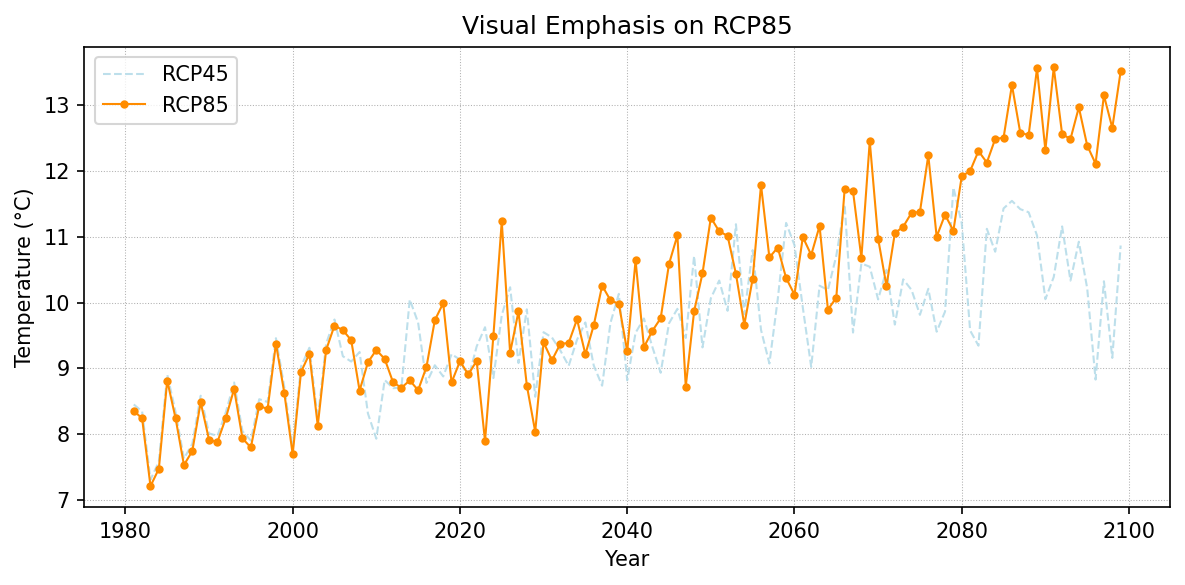

In [26]:
# Prepare annual data
ann = tas.groupby(["scenario", "year"], as_index=False)["value"].mean()
ann = ann.rename(columns={"value": "tas_ann_mean"})

# --- Plot A1: Neutral line chart ---
fig, ax = plt.subplots(figsize=(8, 4))
for scen in ["RCP45", "RCP85"]:
    data = ann[ann["scenario"] == scen]
    ax.plot(data["year"], data["tas_ann_mean"], label=scen, linewidth=1.5)
ax.set_title("Annual Mean Temperature")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.legend()
fig.tight_layout()
plt.show()

# --- Plot A2: Visual emphasis on RCP85 ---
fig, ax = plt.subplots(figsize=(8, 4))
for scen in ["RCP45", "RCP85"]:
    data = ann[ann["scenario"] == scen]
    if scen == "RCP85":
        ax.plot(data["year"], data["tas_ann_mean"], label="RCP85", color="darkorange", linewidth=1.0, marker=".")
    else:
        ax.plot(data["year"], data["tas_ann_mean"], label="RCP45", color="lightblue", linestyle="--", linewidth=1, alpha=0.8)
ax.set_title("Visual Emphasis on RCP85")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.grid(True, linestyle=":", linewidth=0.5)
ax.legend()
fig.tight_layout()
plt.show()


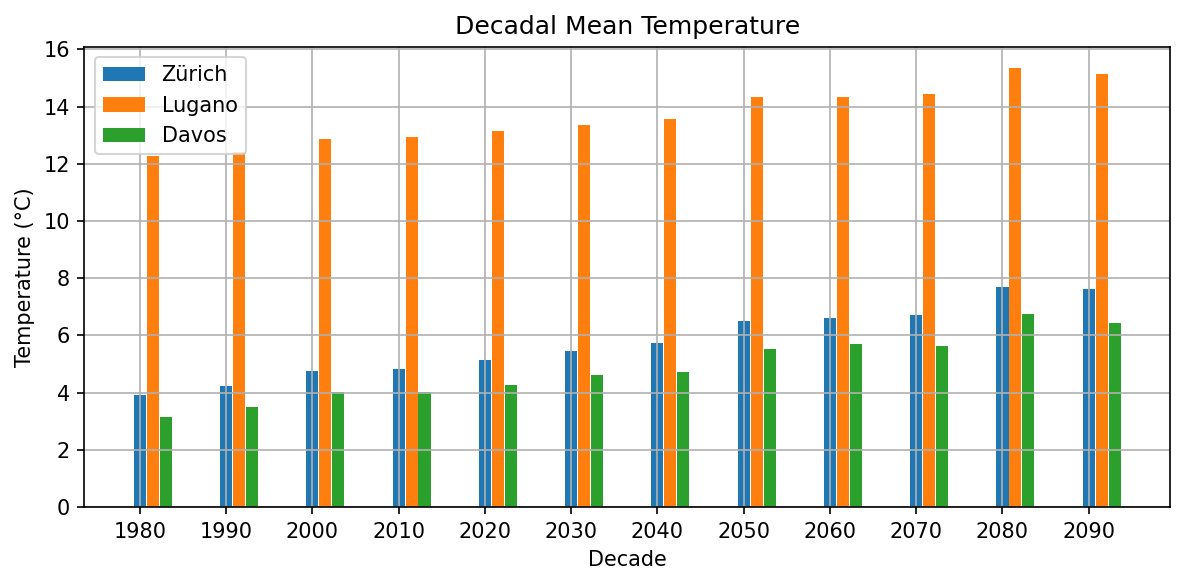

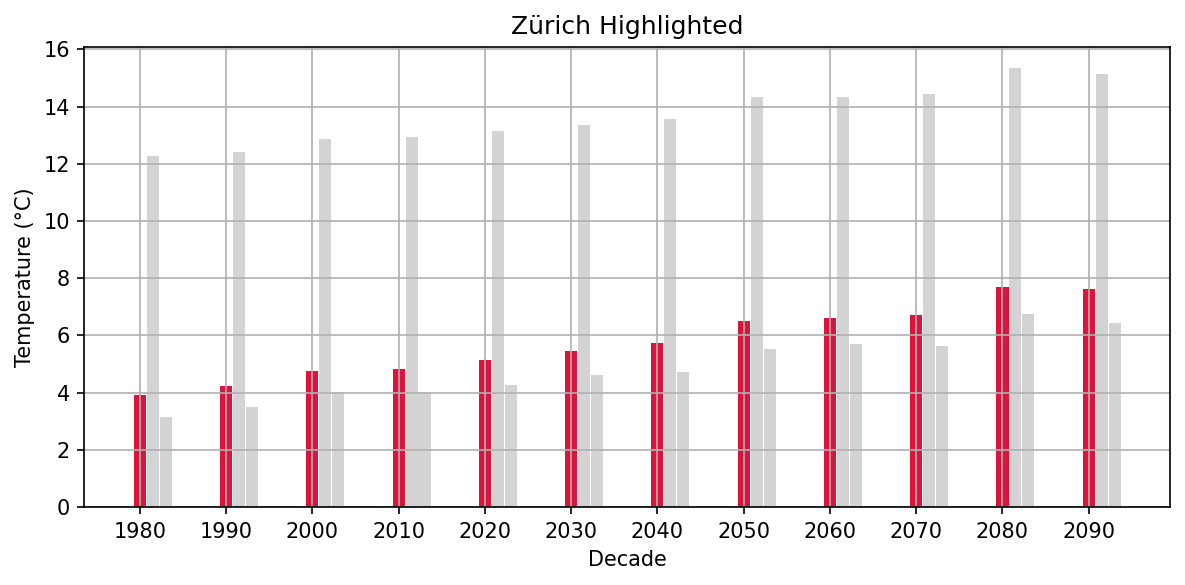

In [29]:
# Prepare decadal means per station
tas["decade"] = (tas["year"] // 10) * 10
decadal = tas.groupby(["station", "decade"], as_index=False)["value"].mean()
decadal = decadal.rename(columns={"value": "tas_dec_mean"})

stations = ["Zürich", "Lugano", "Davos"]

# --- Plot B1: Equal color for all stations ---
fig, ax = plt.subplots(figsize=(8, 4))
for i, station in enumerate(stations):
    data = decadal[decadal["station"] == station]
    ax.bar(data["decade"] + i * 1.5, data["tas_dec_mean"], width=1.4, label=station)
ax.set_title("Decadal Mean Temperature")
ax.set_xlabel("Decade")
ax.set_ylabel("Temperature (°C)")
ax.set_xticks(decadal["decade"].unique())
ax.legend()
fig.tight_layout()
plt.show()

# --- Plot B2: Highlighting Zürich ---
fig, ax = plt.subplots(figsize=(8, 4))
for i, station in enumerate(stations):
    data = decadal[decadal["station"] == station]
    color = "crimson" if station == "Zürich" else "lightgrey"
    ax.bar(data["decade"] + i * 1.5, data["tas_dec_mean"], width=1.4, color=color)
ax.set_title("Zürich Highlighted")
ax.set_xlabel("Decade")
ax.set_ylabel("Temperature (°C)")
ax.set_xticks(decadal["decade"].unique())
fig.tight_layout()
plt.show()


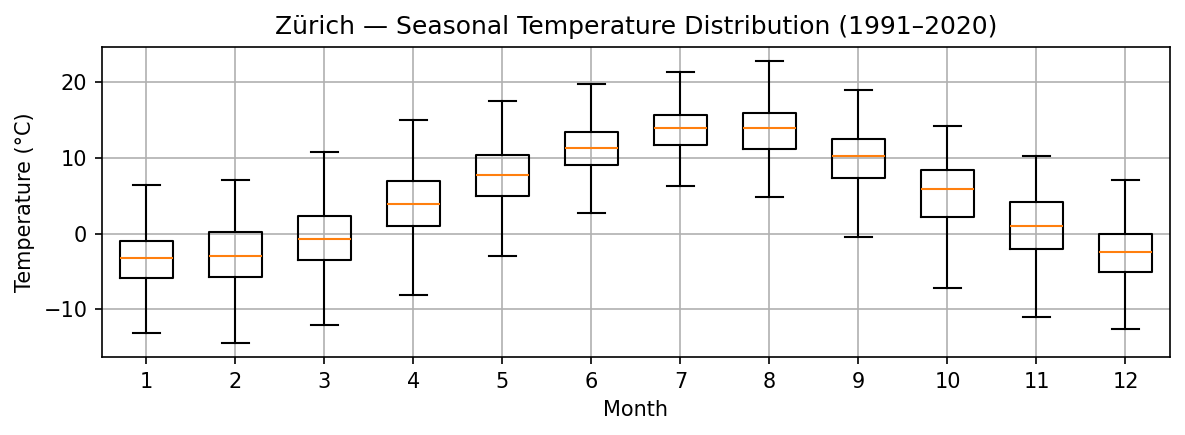

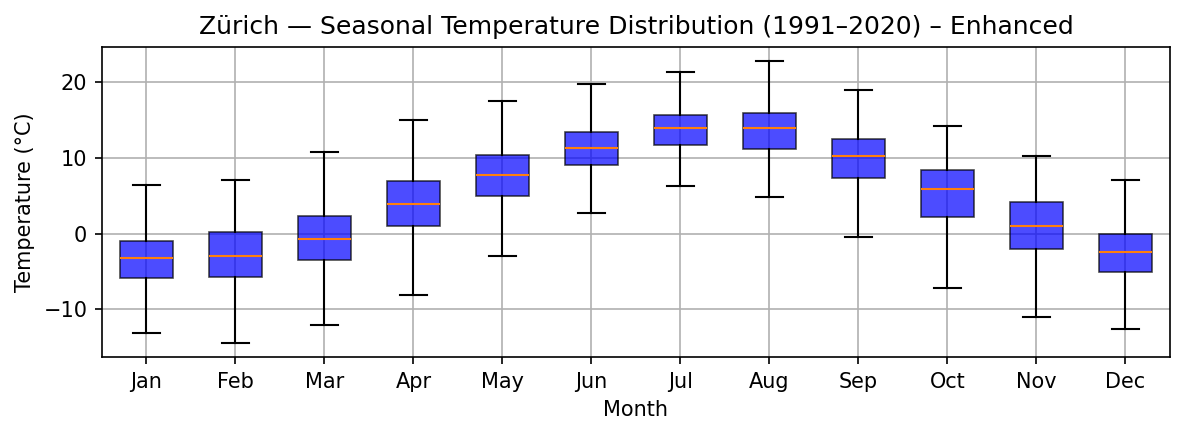

In [12]:
# === Vorbereitung: Datum, Jahr, Monat extrahieren ===
tas["date"] = pd.to_datetime(tas["date"])
tas["year"] = tas["date"].dt.year
tas["month"] = tas["date"].dt.month

# === Subset für gewählte Station ===
chosen_station = "Zürich"
tas_s = tas[tas["station"] == chosen_station]

# === Baseline-Zeitraum festlegen ===
BASELINE_YEARS = (1991, 2020)  # falls noch nicht definiert
y0, y1 = BASELINE_YEARS
base = tas_s[(tas_s["year"] >= y0) & (tas_s["year"] <= y1)]

# === Monatliche Verteilung vorbereiten ===
data_by_month = [base[base["month"] == m]["value"].dropna().values for m in range(1, 13)]

# === LO2 – Figure 2: Seasonal Boxplot – Before Version ===
def plot_fig2_before():
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.boxplot(data_by_month, positions=range(1, 13), widths=0.6, showfliers=False)
    ax.set_title(f"{chosen_station} — Seasonal Temperature Distribution ({y0}–{y1})")
    ax.set_xlabel("Month")
    ax.set_ylabel("Temperature (°C)")
    ax.set_xticks(range(1, 13))
    fig.tight_layout()
    plt.show()

# === LO2 – Figure 2: Seasonal Boxplot – After Version ===
def plot_fig2_after():
    fig, ax = plt.subplots(figsize=(8, 3))
    bp = ax.boxplot(data_by_month, positions=range(1, 13), widths=0.6, showfliers=False, patch_artist=True)

    # Perzeptuelle Verbesserungen
    for patch in bp['boxes']:
        patch.set_facecolor("blue")
        patch.set_alpha(0.7)
        patch.set_linewidth(0.8)

    ax.set_title(f"{chosen_station} — Seasonal Temperature Distribution ({y0}–{y1}) – Enhanced")
    ax.set_xlabel("Month")
    ax.set_ylabel("Temperature (°C)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
    fig.tight_layout()
    plt.show()

# === Beide Varianten ausführen ===
plot_fig2_before()
plot_fig2_after()


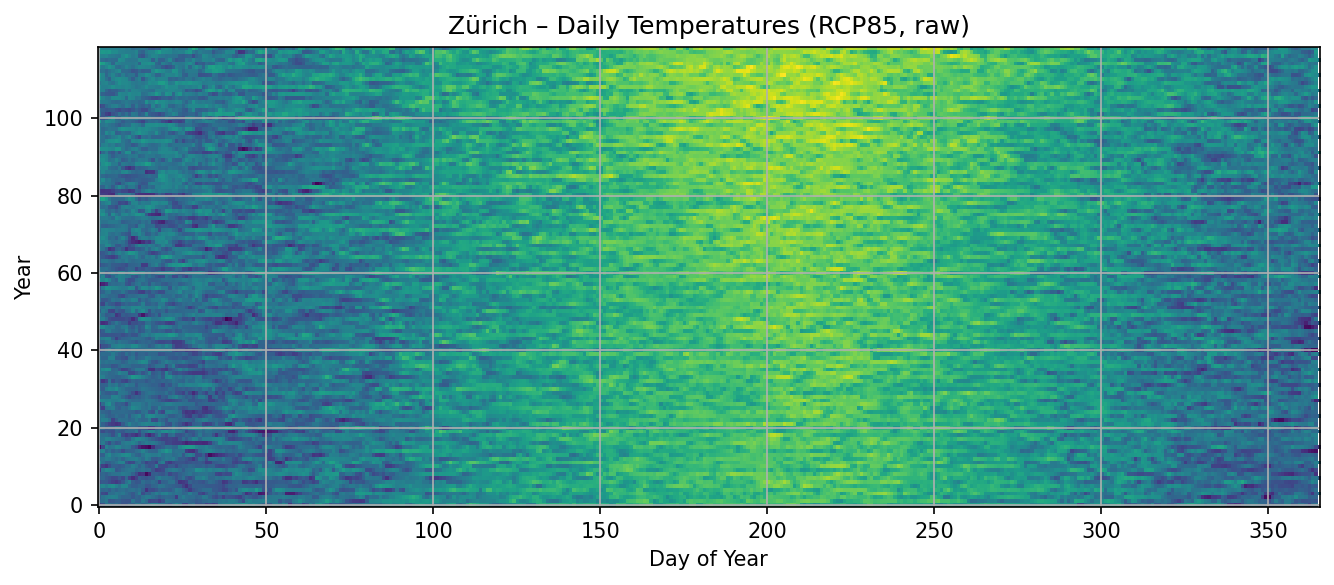

C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_30576\988963917.py:30: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  mat_smooth = mat.rolling(3, axis=1, min_periods=1).mean()


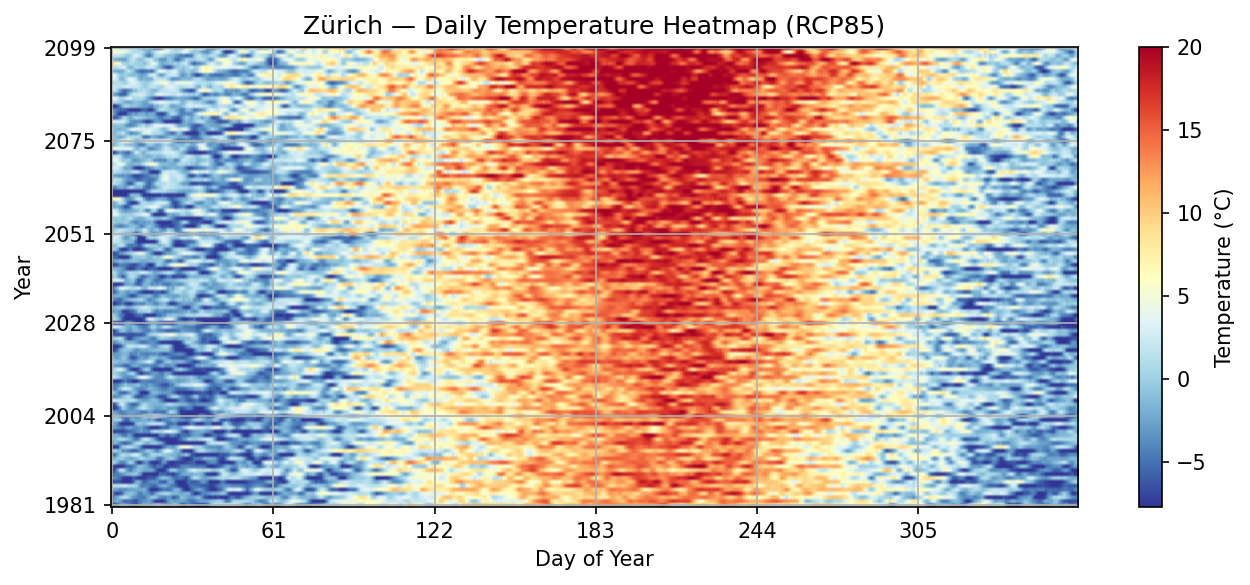

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Parse and extract date components (if not done already) ===
tas["date"] = pd.to_datetime(tas["date"])
tas["year"] = tas["date"].dt.year
tas["month"] = tas["date"].dt.month
tas["doy"] = tas["date"].dt.dayofyear

# === Subset: RCP85 data for selected station ===
tas85_s = tas[(tas["station"] == chosen_station) & (tas["scenario"] == "RCP85")].copy()

# === Pivot to year × day-of-year matrix ===
mat = tas85_s.pivot_table(index="year", columns="doy", values="value", aggfunc="mean")

# === LO2 – Figure 4: Before Version (basic heatmap) ===
def plot_fig4_before():
    fig, ax = plt.subplots(figsize=(9, 4))
    im = ax.imshow(mat.values, aspect="auto", origin="lower")
    ax.set_title(f"{chosen_station} – Daily Temperatures (RCP85, raw)")
    ax.set_xlabel("Day of Year")
    ax.set_ylabel("Year")
    fig.tight_layout()
    plt.show()

# === LO2 – Figure 4: After Version (enhanced heatmap) ===
def plot_fig4_after():
    mat_smooth = mat.rolling(3, axis=1, min_periods=1).mean()
    vmin, vmax = np.nanpercentile(mat_smooth.values, [2, 98])

    fig, ax = plt.subplots(figsize=(9, 4))
    im = ax.imshow(mat_smooth.values, aspect="auto", origin="lower",
                   cmap="RdYlBu_r", vmin=vmin, vmax=vmax)

    ax.set_title(f"{chosen_station} — Daily Temperature Heatmap (RCP85)")
    ax.set_xlabel("Day of Year")
    ax.set_ylabel("Year")

    # Set tidy tick marks
    years = mat.index.values
    yticks = np.linspace(0, len(years)-1, 6, dtype=int)
    ax.set_yticks(yticks)
    ax.set_yticklabels(years[yticks])

    xticks = np.arange(0, 366, 61)
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(int(x)) for x in xticks])

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Temperature (°C)")

    fig.tight_layout()
    plt.show()

# === Run both versions ===
plot_fig4_before()
plot_fig4_after()
